# 00 · Why Uncertainty Matters

*Companion notebook for the chapter* **Introduction: Why Uncertainty Matters**

A standard neural network gives you **one answer** for every input — even for inputs that look nothing like its training data.
In this notebook we see that problem with our own eyes and meet the two kinds of uncertainty that Bayesian Neural Networks (BNNs) try to capture.

**You will learn**
1. What *uncertainty quantification* (UQ) means.
2. Why a traditional neural network is over-confident away from its data.
3. The difference between **aleatoric** (data noise) and **epistemic** (model/knowledge) uncertainty.
4. The core idea of *Bayesian thinking*: keep **many plausible models** instead of one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. A toy problem with a gap in the data

The true function is $f(x) = \sin(x)$ and every observation carries Gaussian noise:

$$y = \sin(x) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0.1^2)$$

We only observe $x$ in two regions, $[-4,-1.5]$ and $[1.5, 4]$. Between and outside them, the network has **never seen data**.

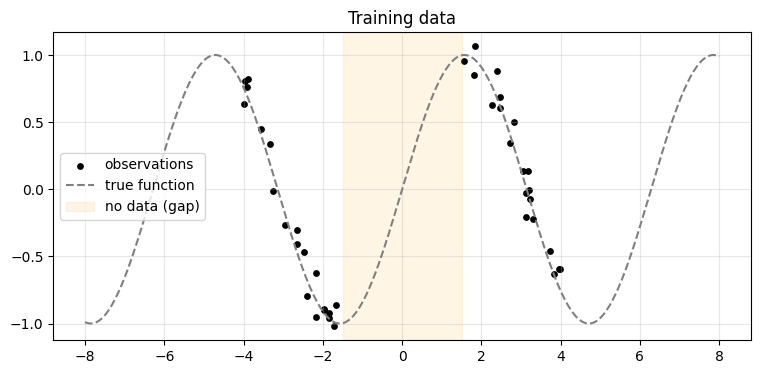

In [2]:
def make_data(n=40, noise=0.1):
    x = np.concatenate([rng.uniform(-4, -1.5, n // 2), rng.uniform(1.5, 4, n // 2)])
    y = np.sin(x) + noise * rng.standard_normal(n)
    return x[:, None], y

X, y = make_data()
x_grid = np.linspace(-8, 8, 400)[:, None]

plt.scatter(X, y, c="k", s=15, label="observations")
plt.plot(x_grid, np.sin(x_grid), "--", c="gray", label="true function")
plt.axvspan(-1.5, 1.5, color="orange", alpha=0.1, label="no data (gap)")
plt.legend(); plt.title("Training data"); plt.show()

## 2. A traditional neural network: one confident answer

We train a single multilayer perceptron (MLP). It returns a single number $\hat y(x)$ for every $x$ — there is no notion of *"I am not sure"*.

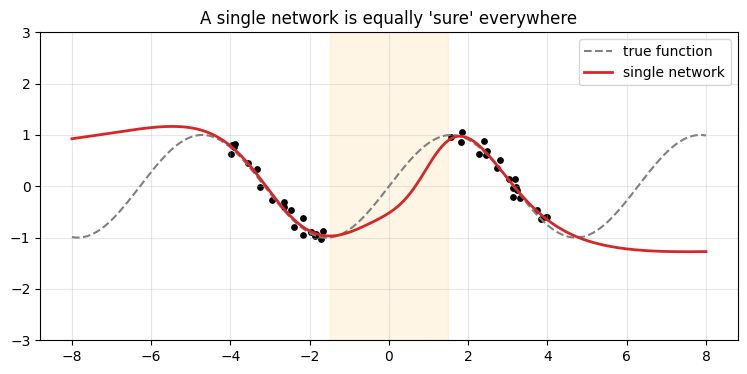

In [3]:
net = MLPRegressor(hidden_layer_sizes=(50, 50), activation="tanh", solver="lbfgs", max_iter=5000, random_state=1)
net.fit(X, y)

plt.scatter(X, y, c="k", s=15)
plt.plot(x_grid, np.sin(x_grid), "--", c="gray", label="true function")
plt.plot(x_grid, net.predict(x_grid), c="C3", lw=2, label="single network")
plt.axvspan(-1.5, 1.5, color="orange", alpha=0.1)
plt.ylim(-3, 3); plt.legend(); plt.title("A single network is equally 'sure' everywhere"); plt.show()

Far from the data (e.g. $x=7$) the network still outputs a definite value. Nothing in the output warns us that this value is essentially a guess.
In a **safety-critical** setting (medicine, autonomous driving, finance) that is dangerous.

## 3. Bayesian thinking: many plausible networks

Many different weight settings explain the training data about equally well. Instead of betting on one, Bayesian thinking says:
**keep all the plausible ones and weigh them by how plausible they are.**

A cheap way to *approximate* this idea is to train several networks from different random starts (a *deep ensemble*). Proper Bayesian methods come later in the course — here we only want the intuition.

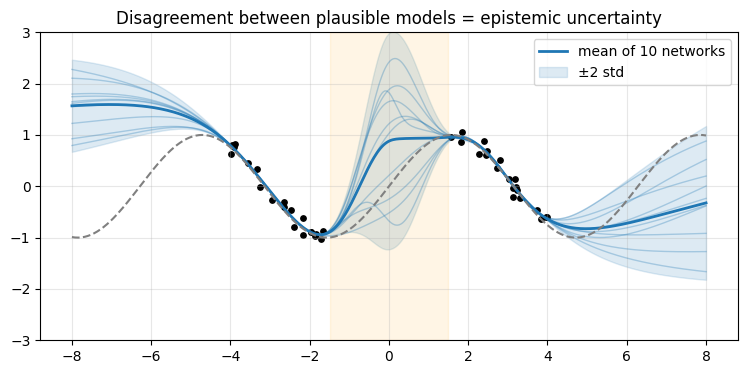

In [4]:
preds = []
for seed in range(10):
    m = MLPRegressor(hidden_layer_sizes=(50, 50), activation="tanh", solver="lbfgs", max_iter=5000, random_state=seed)
    m.fit(X, y)
    preds.append(m.predict(x_grid))
preds = np.array(preds)                    # shape (10, 400)
mean, std = preds.mean(0), preds.std(0)

fig, ax = plt.subplots()
for p in preds:
    ax.plot(x_grid, p, c="C0", alpha=0.3, lw=1)
ax.plot(x_grid, mean, c="C0", lw=2, label="mean of 10 networks")
ax.fill_between(x_grid.ravel(), mean - 2 * std, mean + 2 * std, color="C0", alpha=0.15, label="±2 std")
ax.scatter(X, y, c="k", s=15)
ax.plot(x_grid, np.sin(x_grid), "--", c="gray")
ax.axvspan(-1.5, 1.5, color="orange", alpha=0.1)
ax.set_ylim(-3, 3); ax.legend(); ax.set_title("Disagreement between plausible models = epistemic uncertainty")
plt.show()

Where there is data, the networks **agree**; where there is none, they **disagree**. The spread is a measure of what the model *does not know*.

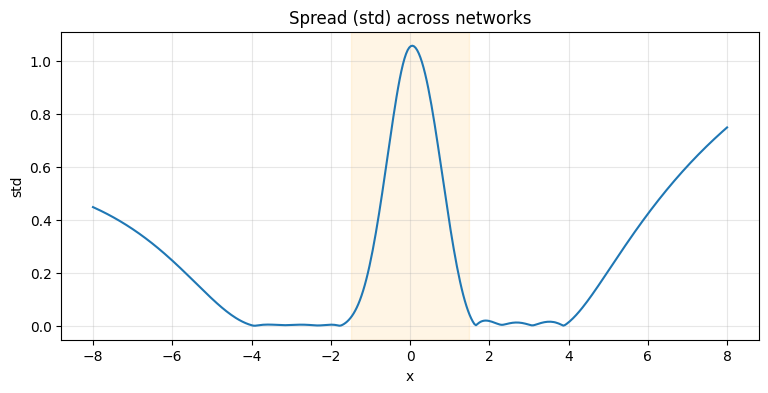

In [5]:
plt.plot(x_grid, std, c="C0")
plt.axvspan(-1.5, 1.5, color="orange", alpha=0.1)
plt.title("Spread (std) across networks"); plt.xlabel("x"); plt.ylabel("std"); plt.show()

## 4. Two kinds of uncertainty

| | **Aleatoric** uncertainty | **Epistemic** uncertainty |
|---|---|---|
| Source | Noise in the data itself ($\varepsilon$ above) | Lack of knowledge about the right model/weights |
| Reduced by more data? | **No** | **Yes** |
| Example | A sensor that is always ±0.1 inaccurate | Predicting in a region with no training data |

A full predictive model should report both. In the Bayesian framework the predictive variance splits as

$$\operatorname{Var}[y^*] = \underbrace{\mathbb{E}_{\mathbf w}\big[\sigma^2\big]}_{\text{aleatoric}} + \underbrace{\operatorname{Var}_{\mathbf w}\big[f_{\mathbf w}(x^*)\big]}_{\text{epistemic}}$$

which we will compute explicitly in notebook 04.

### Check: epistemic uncertainty shrinks with data

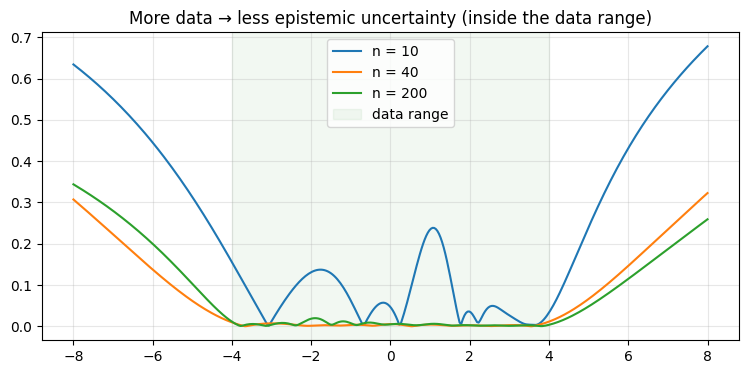

In [6]:
def ensemble_std(n, seeds=8):
    Xn = rng.uniform(-4, 4, n)[:, None]
    yn = np.sin(Xn.ravel()) + 0.1 * rng.standard_normal(n)
    P = [MLPRegressor(hidden_layer_sizes=(50, 50), activation="tanh", solver="lbfgs", max_iter=4000, random_state=s).fit(Xn, yn).predict(x_grid) for s in range(seeds)]
    return np.std(P, axis=0)

for n in [10, 40, 200]:
    plt.plot(x_grid, ensemble_std(n), label=f"n = {n}")
plt.axvspan(-4, 4, color="green", alpha=0.05, label="data range")
plt.legend(); plt.title("More data → less epistemic uncertainty (inside the data range)"); plt.show()

## Summary
* A traditional neural network returns a **point prediction** and no warning when it extrapolates.
* **Uncertainty quantification** adds an honest "how sure am I?" to each prediction.
* **Bayesian Neural Networks** treat the weights as *random variables* and average predictions over all plausible weights.

To do this properly we need probability theory (notebook 01) and the mathematics of neural networks (notebook 02).

## Exercises
1. Change the noise level to `0.3`. Which uncertainty grows — the spread between networks inside the data region, or the scatter of the points?
2. Replace `activation="tanh"` with `"relu"`. How does the ensemble behave far outside the data ($|x| > 6$)?
3. Why is an ensemble of 10 networks only an *approximation* of Bayesian inference? (Hint: are the 10 networks weighted by their posterior probability?)